In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
#import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold

# Introducción a regresión logística

Vamos a trabajar con un dataset de churn bancario. Es decir, se tiene interés en la propensión a que un cliente deje de ser cliente de un banco.

In [2]:
# La raw URL del CSV en GitHub
url = 'https://raw.githubusercontent.com/EduardoSelimMM/2026PrimaveraUP_ML/refs/heads/main/sesion19/bank_churn.csv'

# Se lee el CSV y se guarda en un pandas DataFrame
df = pd.read_csv(url)

In [3]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


+ En este caso, la variable respuesta es `Exited`. Donde 1 significa que el cliente abandonó al banco y 0 que sigue siendo cliente.

+ Inicialmente se considerarán como variables explicativas:

  + `CreditScore`: Calificación crediticia
  + `Age`: Edad
  + `Tenure`: Antiguedad como cliente
  + `Balance`: Saldo en su cuenta bancaria
  + `NumOfProducts`: Número de productos con el banco
  + `EstimatedSalary`: Salario estimado

In [4]:
# Ya saben nos gusta conocer las dimensiones de nuestro DataFrame
df.shape

(10000, 13)

In [5]:
# Se aplica el método info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [6]:
# Sin mucho análisis o justificación se quitarán los NAs
df = df.dropna()

In [7]:
# El tamaño de nuestro dataset
df.shape

(10000, 13)

In [8]:
df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

+ Veamos si alguna de las variables explicativas tiene el ''poder'' de explicar si un cliente abandonará el banco o no.

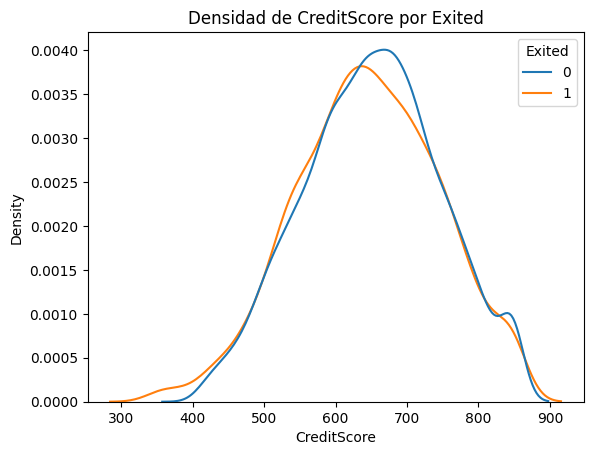

In [9]:
sns.kdeplot(data = df, x = 'CreditScore', hue = 'Exited', common_norm=False)

plt.title("Densidad de CreditScore por Exited")
plt.show()

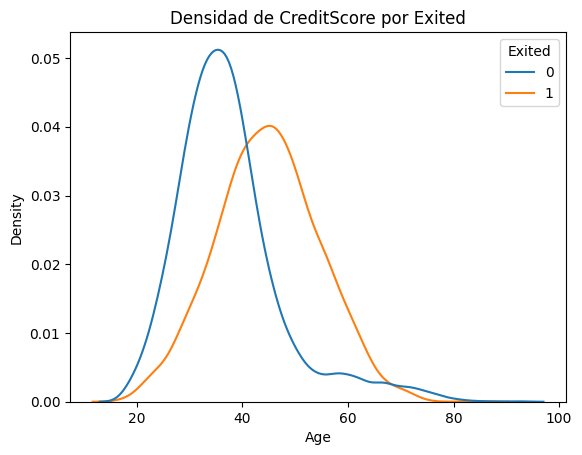

In [10]:
sns.kdeplot(data = df, x = 'Age', hue = 'Exited', common_norm=False)

plt.title("Densidad de CreditScore por Exited")
plt.show()

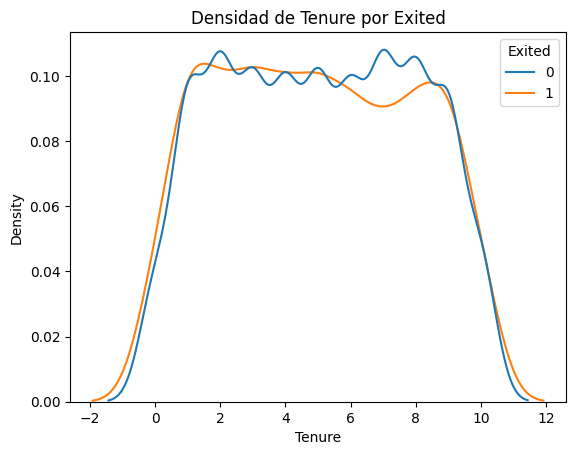

In [11]:
sns.kdeplot(data = df, x = 'Tenure', hue = 'Exited', common_norm=False)

plt.title("Densidad de Tenure por Exited")
plt.show()

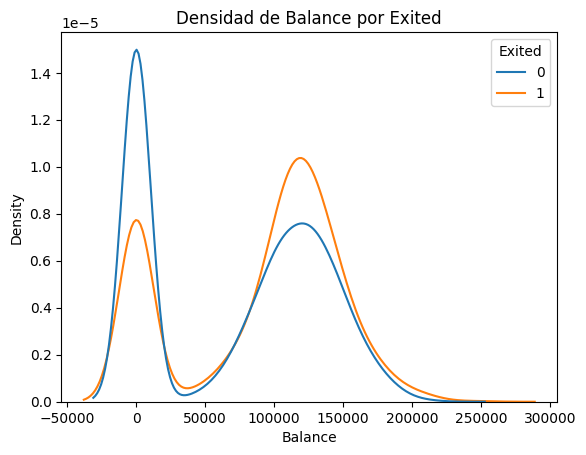

In [12]:
sns.kdeplot(data = df, x = 'Balance', hue = 'Exited', common_norm=False)

plt.title("Densidad de Balance por Exited")
plt.show()

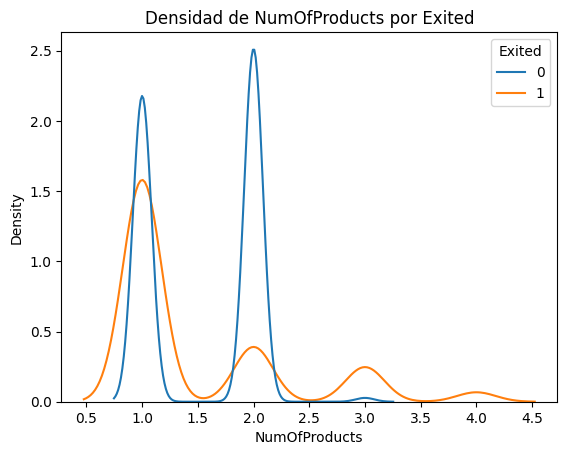

In [13]:
sns.kdeplot(data = df, x = 'NumOfProducts', hue = 'Exited', common_norm=False)

plt.title("Densidad de NumOfProducts por Exited")
plt.show()

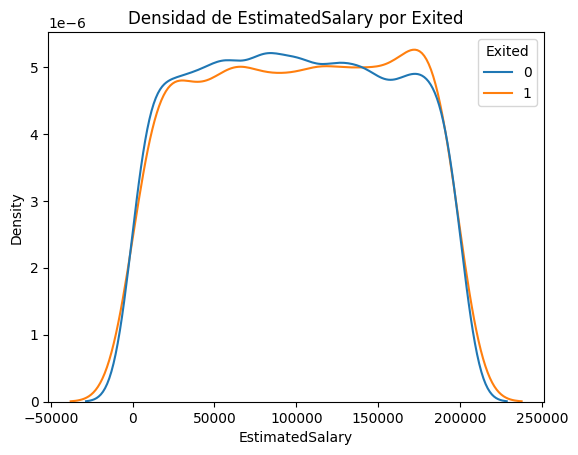

In [14]:
sns.kdeplot(data = df, x = 'EstimatedSalary', hue = 'Exited', common_norm=False)

plt.title("Densidad de EstimatedSalary por Exited")
plt.show()

In [15]:
# Se define la variable respuesta (y) y las variables explicativas (X)
y = df['Exited']
variables_explicativas = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
X = df[variables_explicativas]

In [16]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
0,619,42,2,0.00,1,101348.88
1,608,41,1,83807.86,1,112542.58
2,502,42,8,159660.80,3,113931.57
3,699,39,1,0.00,2,93826.63
4,850,43,2,125510.82,1,79084.10


In [17]:
# División de datos (Entrenamiento y Prueba)
# 20% como datos de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2026)

In [18]:
print(f"Tamaño del training set: {X_train.shape[0]}")
print(f"Tamaño de testing set: {X_test.shape[0]}")

Tamaño del training set: 8000
Tamaño de testing set: 2000


In [19]:
# Escalado de variables
# Importante: El sueldo y el saldo tienen magnitudes muy distintas al 'Tenure'
scaler = StandardScaler()
# IMPORTANTE: Con X_train se obtienen las medias y desviaciones para escalar
# Por eso se usa fit_transform()
# En X_test se escala con las medias y desviaciones que se obtuvieron anteriormente
# Por eso se usa sólo transform()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
# Creación y entrenamiento del modelo
## Le decimos a Python que haré una regresión logística
modelo_logistico = LogisticRegression()
## Se entrena el modelo
modelo_logistico.fit(X_train_scaled, y_train)

LogisticRegression()

In [21]:
# Obtenemos las predicciones del modelo sobre las observaciones de entrenamiento
y_pred_train = modelo_logistico.predict(X_train_scaled)
# Obtenemos las predicciones del modelo sobre las observaciones de test
y_pred_test = modelo_logistico.predict(X_test_scaled)

In [22]:
# Calculamos una métrica para problemas de clasificación: accuracy
# Porcentaje de observaciones que la predicción fue correcta
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy en el dataset de entrenamiento: {accuracy_train}")
print(f"Accuracy en el dataset de prueba: {accuracy_test}")

Accuracy en el dataset de entrenamiento: 0.7775
Accuracy en el dataset de prueba: 0.791


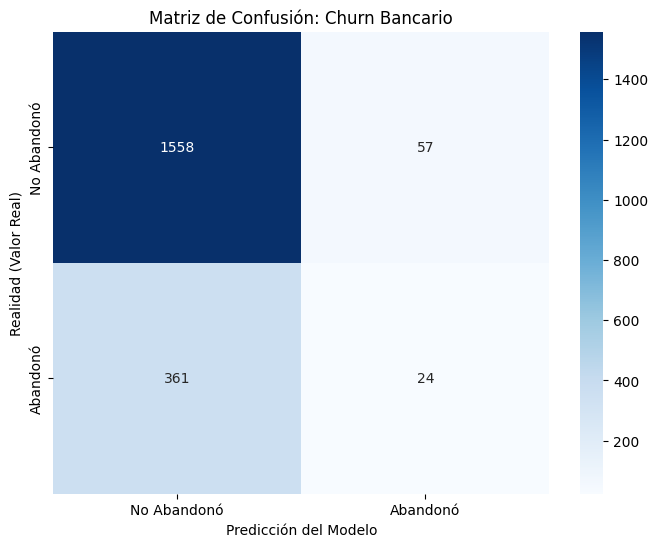

In [23]:
# Se obtiene la matriz de confusión sobre los datos de prueba
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

# Graficamos
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Abandonó', 'Abandonó'],
            yticklabels=['No Abandonó', 'Abandonó'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Valor Real)')
plt.title('Matriz de Confusión: Churn Bancario')
plt.show()

+ Recuérdese que en este caso "1" significa que la persona abandonó al banco.
+ **Verdaderos positivos** = Personas que son 1 y el modelo predijo que son efectivamente 1 = Personas que abandonaron y el modelo predijo que abandonaros = 24
+ **Verdaderos negativos** = Personas que son 0 y el modelo predijo que son efectivamente 0 = Personas que siguen siendo clientes y el modelo predijo que siguen siendo clientes = 1558
+ **Falsos positivos** = Personas que son 0 pero el modelo predijo que son 1 = Personas que siguen siendo clientes pero el modelo predijo que abandonarían = 57
+ **Falsos negativos** = Personas que son 1 pero el modelo predijo que son 0 = Personas que abandonaron pero el modelo predijo que se quedarían = 361
+ ¿Qué les interesa controlar? ¿Falsos negativos o Falsos positivos?

$$\text{Recall}=\frac{\text{Verdaderos positivos}}{\text{Positivos}} = \frac{TP}{TP + FN}$$

$$\text{Precision} = \frac{\text{Verdaderos positivos}}{\text{El modelo dijo positivos}} = \frac{TP}{TP + FP}$$

$$\text{Tasa Falsos Negativos} = \frac{\text{Falsos negativos}}{\text{Positivos}} = \frac{FN}{TP+FN}$$

$$\text{Tasa Falsos Positivos} = \frac{\text{Falsos positivos}}{\text{Negativos}} = \frac{FP}{TN+FP}$$

$$\text{Especificidad} = \frac{\text{Verdaderos negativos}}{\text{Negativos}} = \frac{TN}{TN+FP}$$

In [24]:
print(f"Recall: {recall_score(y_test, y_pred_test)}")
print(f"Precision: {precision_score(y_test, y_pred_test)}")
print(f"Tasa Falsos Negativos: {fn / (tp + fn)}")
print(f"Tasa Falsos Positivos: {fp / (tn + fp)}")
print(f"Especificidad: {tn / (tn + fp)}")

Recall: 0.06233766233766234
Precision: 0.2962962962962963
Tasa Falsos Negativos: 0.9376623376623376
Tasa Falsos Positivos: 0.03529411764705882
Especificidad: 0.9647058823529412


+ Recuérdese que en regresión logística lo que se predice es la probabilidad de ser 1, dadas las variables explicativa
$$\mathbb{P}(Y=1|X_1,\ldots,X_p)$$

+ Cuando hago `modelo_logistico.fit(X_train_scaled)`, Python estima dicha probabilidad.

+ Cuando hago `modelo_logistico.predict(X_train_scaled)` o `modelo_logistico.predict(X_test_scaled)`, Python dice: Si tu probabilidad estimada es mayor que 1/2, entonces eres 1. Si tu probabilidad estimada es menor que 1/2, entonces eres 0.

+ Es decir, toma a 1/2 como umbral de decisión entre ser 0 ó 1.

+ De hecho, podemos obtener las probabilidades estimadas

In [25]:
# En lugar de usar .predict(), usamos .predict_proba()
# Esto nos da la probabilidad estimada de ser 1
probabilidades_test = modelo_logistico.predict_proba(X_test_scaled)[:, 1]

In [26]:
probabilidades_test

array([0.0976641 , 0.17470026, 0.1343988 , ..., 0.11832689, 0.11512236,
       0.14059551])

+ ¿Qué pasa si cambiamos el umbral?

In [27]:
# Aplicamos un umbral más bajo (ej. 0.3)
umbral = 0.3
y_test_pred_30 = (probabilidades_test > umbral).astype(int)
y_test_pred_30

array([0, 0, 0, ..., 0, 0, 0])

Matriz con umbral 0.3:


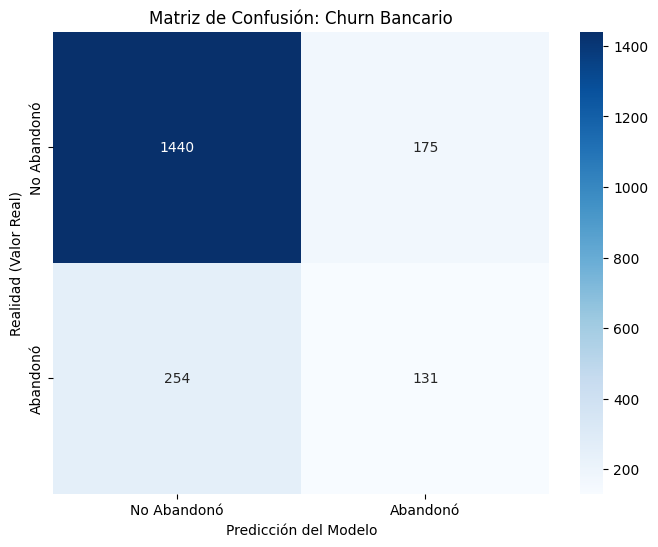

In [28]:
# Comparamos la nueva matriz de confusión
cm_30 = confusion_matrix(y_test, y_test_pred_30)
tn_30, fp_30, fn_30, tp_30 = confusion_matrix(y_test, y_test_pred_30).ravel()

print(f"Matriz con umbral {umbral}:")
# Graficamos
plt.figure(figsize=(8, 6))
sns.heatmap(cm_30, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Abandonó', 'Abandonó'],
            yticklabels=['No Abandonó', 'Abandonó'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Valor Real)')
plt.title('Matriz de Confusión: Churn Bancario')
plt.show()

In [29]:
# Se calcula el precision y recall con este nuevo umbral
print(f"Recall: {recall_score(y_test, y_test_pred_30)}")
print(f"Precision: {precision_score(y_test, y_test_pred_30)}")
print(f"Tasa Falsos Negativos: {fn_30 / (tp_30 + fn_30)}")
print(f"Tasa Falsos Positivos: {fp_30 / (tn_30 + fp_30)}")
print(f"Especificidad: {tn_30 / (tn_30 + fp_30)}")

Recall: 0.34025974025974026
Precision: 0.42810457516339867
Tasa Falsos Negativos: 0.6597402597402597
Tasa Falsos Positivos: 0.10835913312693499
Especificidad: 0.891640866873065


¿Qué sucede al bajar el umbral?

+ El modelo se vuelve mucho más "desconfiado" o sensible. Básicamente, se le está diciendo que "ante la más mínima duda de que un cliente se pueda ir, márcalo como una posible baja".

+ Aumenta el recall (sensibilidad): Esta es la principal ventaja. Al "bajar la vara", se "atrapa" a la gran mayoría de los clientes que realmente tienen intención de abandonar el banco. Se minimiza a los Falsos Negativos (clientes que se van sin que el modelo te avisara).

+ Idealmente, disminuye la precisión. El costo de ser tan sensible es que se tendrá muchos Falsos Positivos. El modelo señalará a muchos clientes como "en riesgo de irse" cuando en realidad son clientes leales. Si la estrategia de retención implica llamadas telefónicas o descuentos, se estará desperdiciando recursos en personas que no los necesitaban. En nuestro caso no pasa ¿porqué?

In [30]:
# Aplicamos un umbral más alto (ej. 0.7)
umbral = 0.7
y_test_pred_70 = (probabilidades_test > umbral).astype(int)

Matriz con umbral 0.7:


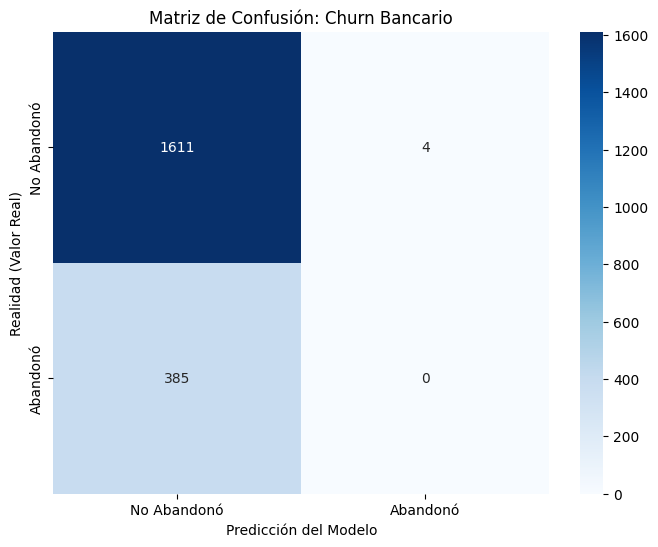

In [31]:
# Comparamos la nueva matriz de confusión
cm_70 = confusion_matrix(y_test, y_test_pred_70)
tn_70, fp_70, fn_70, tp_70 = confusion_matrix(y_test, y_test_pred_70).ravel()

print(f"Matriz con umbral {umbral}:")
# Graficamos
plt.figure(figsize=(8, 6))
sns.heatmap(cm_70, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Abandonó', 'Abandonó'],
            yticklabels=['No Abandonó', 'Abandonó'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Valor Real)')
plt.title('Matriz de Confusión: Churn Bancario')
plt.show()

In [32]:
# Se calcula el precision y recall con este nuevo umbral
print(f"Recall: {recall_score(y_test, y_test_pred_70)}")
print(f"Precision: {precision_score(y_test, y_test_pred_70)}")
print(f"Tasa Falsos Negativos: {fn_70 / (tp_70 + fn_70)}")
print(f"Tasa Falsos Positivos: {fp_70 / (tn_70 + fp_70)}")
print(f"Especificidad: {tn_70 / (tn_70 + fp_70)}")

Recall: 0.0
Precision: 0.0
Tasa Falsos Negativos: 1.0
Tasa Falsos Positivos: 0.002476780185758514
Especificidad: 0.9975232198142415


¿Qué sucede al subir el umbral?

+ Nos estamos volviendo mucho más "exigentes" para clasificar a alguien como un cliente que abandonará el banco.

+ Idealmente, aumenta la precisión: Al ser más estrictos, se cometerán menos errores al predecir quién se va. Si el modelo dice que un cliente se marcha, es casi seguro que así será. Esto es ideal si la acción de retención es muy costosa (por ejemplo, regalar una anualidad de tarjeta de crédito). En nuestro caso no pasa ¿porqué?

+ Disminuye el recall (sensibilidad). Este es el efecto negativo. Al poner la vara tan alta, muchos clientes que tienen una probabilidad de irse del 0.55 o 0.6 serán clasificados como "leales" (`Exited = 0`). El banco no hará nada por ellos y terminarán abandonando la institución sin que te des cuenta.

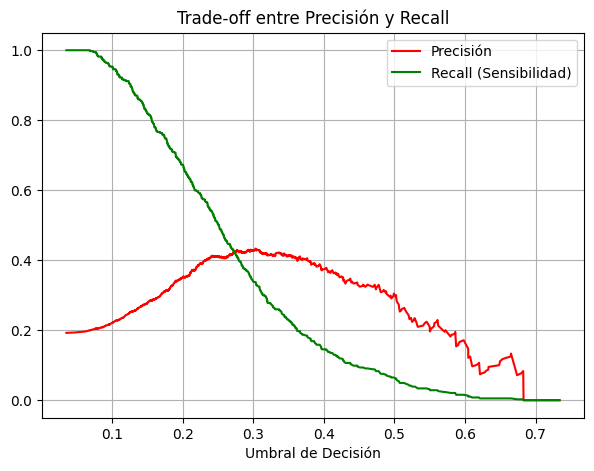

In [33]:
# Se puede graficar tanto la precisión como el recall para cada umbral
# Especificamos explícitamente que el '1' es el evento que nos interesa (el abandono)
precision, recall, thresholds = precision_recall_curve(y_test, probabilidades_test, pos_label=1)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], label="Precisión", color="red")
plt.plot(thresholds, recall[:-1], label="Recall (Sensibilidad)", color="green")
plt.xlabel("Umbral de Decisión")
plt.title("Trade-off entre Precisión y Recall")
plt.legend()
plt.grid(True)
plt.show()

+ Siempre hay dos fuerzas en conflicto. La curva muestra una relación inversa (un *trade-off*). Casi siempre, cuando se intenta mejorar una, la otra empeora:

+ Recall (sensibilidad) es la habilidad del modelo para encontrar a todos los clientes que se van. Si se quieres un recall del 100%, el umbral sería 0, se creería que todos los clientes huirán y se tendría que llamar a todos los clientes del banco.

+ En este contexto, la precisión, es lo que se conoce como la "seguridad" del modelo. Si el modelo dice que 10 personas se van y las 10 se van realmente, tu precisión es del 100%. Pero para lograr esto, el modelo suele volverse muy tímido y sólo señala a los casos más obvios, dejando escapar a muchos otros.

+ El inicio de ambas curvas representa umbral bajo. En este caso el recall es alto (atrapas a todos), pero la precisión es baja (se comenten muchos errores y se marca a gente leal como "fugas").

+ El final de ambas curvas reprenta umbral alto. La precisión idealmente deber ser alta (el modelo acierta), pero el recall cae (se te escapan casi todos los clientes que se van). En nuestro caso no pasa ¿porqué?

+ El "punto de equilibrio" es el cruce de ambas curvas. Suele ser un buen punto de partida para un modelo balanceado, aunque no siempre es el óptimo para el negocio.

## Recomendación de BI dev

+ Si el costo de retención es bajo (ej. enviar un email automático): Te conviene un recall alto. No importa que la precisión baje un poco, prefieres "pecar de precavido" y enviarle el correo a alguien que no se iba a ir.

+ Si el costo de retención es alto (ej. ofrecer un bono en efectivo o una tasa preferencial): Te conviene una precisión alta. Sólo quieres aplicar la promoción a quienes estás muy seguro de que están por abandonar el banco, para no regalar dinero innecesariamente.

## La curva ROC

+ La curva ROC (Receiver Operating Characteristic) es una herramienta gráfica para evaluar el rendimiento de un modelo de clasificación binaria, especialmente cuando este genera probabilidades en lugar de etiquetas directas (0 o 1).
+ La curva ROC surge de variar el umbral desde 0 hasta 1 y ver cómo cambian los errores y aciertos del modelo.

  + Eje Y: Tasa de Verdaderos Positivos (i.e el recall)
  + Eje X: Tasa de Falsos Positivos

+ El Área Bajo la Curva (AUC). Para resumir la calidad del modelo en un solo número, usamos el AUC (Area Under the Curve):

  + AUC = 0.5: El modelo no tiene capacidad de discriminación (es azar).
  + AUC entre 0.7 y 0.8: Se considera un modelo aceptable.
  + AUC entre 0.8 y 0.9: Excelente capacidad predictiva.
  + AUC = 1.0: El modelo es perfecto; separa las clases sin ningún error. AUUUUUUNQUE hay que desconfiar de un modelo tan perfecto.

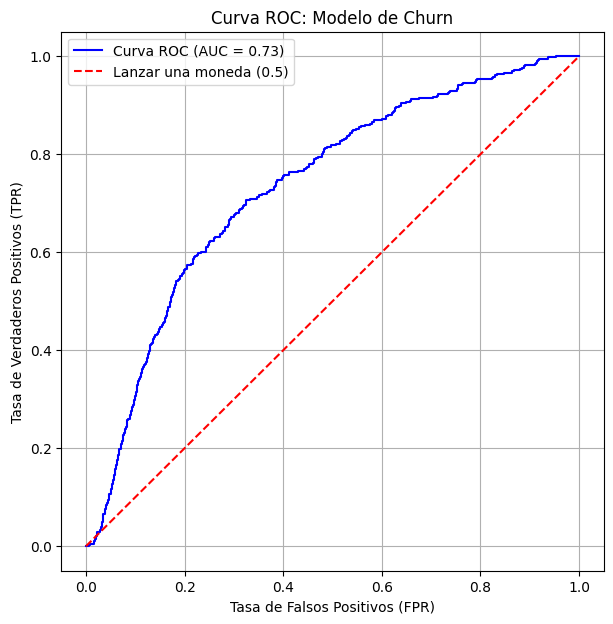

In [34]:
# Recuerda: probabilidades es la columna [:, 1] de predict_proba
fpr, tpr, thresholds = roc_curve(y_test, probabilidades_test)

# 2. Calculamos el área bajo la curva (AUC)
auc = roc_auc_score(y_test, probabilidades_test)

# 3. Dibujamos
plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Lanzar una moneda (0.5)') # Línea de referencia

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC: Modelo de Churn')
plt.legend()
plt.grid(True)
plt.show()

+ La diagonal es una línea recta desde (0,0) a (1,1) representa un modelo que clasifica al azar (como lanzar una moneda).

+ La curva hacia la esquina superior izquierda: Cuanto más se aleje la curva de la diagonal y se acerque a la esquina superior izquierda (donde $TPR=1$ y $FPR=0$), mejor es el modelo.

+ En nuestro caso, la curva no está tan pegada a la esquina superior izquierda como querríamos :(

## ¿Qué está pasando?

+ Primera hipótesis: Las clases están desbalanceadas, i.e. hay muchos 1s y pocos 0s, o viceversa.

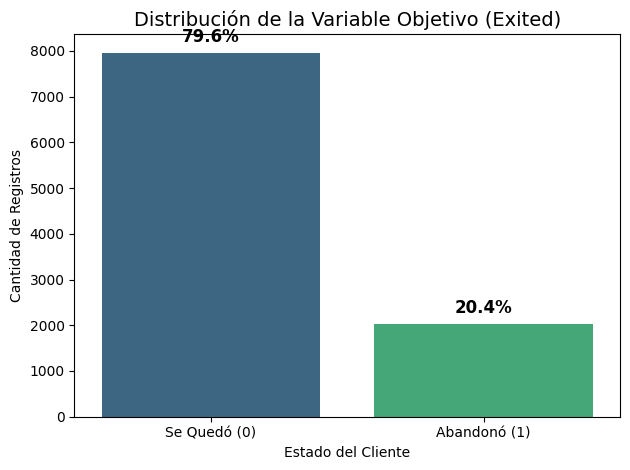

In [35]:
# Se cuentan cuántos 0s y cuántos 1s hay
ax = sns.countplot(data=df, x='Exited', hue='Exited', palette='viridis', legend=False)
total = len(df['Exited'])
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = height
    ax.annotate(percentage, (x, y), ha='center', va='bottom',
                fontsize=12, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.title('Distribución de la Variable Objetivo (Exited)', fontsize=14)
plt.xticks([0, 1], ['Se Quedó (0)', 'Abandonó (1)'])
plt.xlabel('Estado del Cliente')
plt.ylabel('Cantidad de Registros')

plt.tight_layout()
plt.show()

+ Como se puede ver, hay demasiados 0s y pocos 1's. Esto no permite identificar bien a los 1's. Se pierden en el mar de 0s durante el entrenamiento.

+ Por defecto, la Regresión Logística trata a todas las observaciones por igual (peso = 1).

+ Cuando se incluye el parámetro `class_weight='balanced'`, el algoritmo calcula automáticamente pesos inversamente proporcionales a las frecuencias de clase en los datos de entrada:
$$w_j = \frac{\text{num. de observaciones}}{2 \cdot \text{Núm. de obs que pertenecen a la clase }j}$$

+ **OJO:** El modelo **no** cambia los datos, sino que modifica la función de pérdida (Log-Loss).

+ Si el modelo comete un error al clasificar la clase minoritaria, la penalización es mucho mayor que si se equivoca con la clase mayoritaria.

+ Esto obliga al optimizador a prestar más atención a los patrones que definen a la clase escasa para minimizar el error total ponderado.

In [36]:
# Se define un nuevo modelo que penaliza los errores en la clase de 1's (que es la minoritaria)
modelo_balanceado = LogisticRegression(class_weight='balanced')
modelo_balanceado.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced')

In [37]:
# Obtenemos las predicciones del modelo sobre las observaciones de entrenamiento
y_pred_train = modelo_balanceado.predict(X_train_scaled)
# Obtenemos las predicciones del modelo sobre las observaciones de test
y_pred_test = modelo_balanceado.predict(X_test_scaled)

# Calculamos una métrica para problemas de clasificación: accuracy
# Porcentaje de observaciones que la predicción fue correcta
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy en el dataset de entrenamiento: {accuracy_train}")
print(f"Accuracy en el dataset de prueba: {accuracy_test}")

Accuracy en el dataset de entrenamiento: 0.707
Accuracy en el dataset de prueba: 0.721


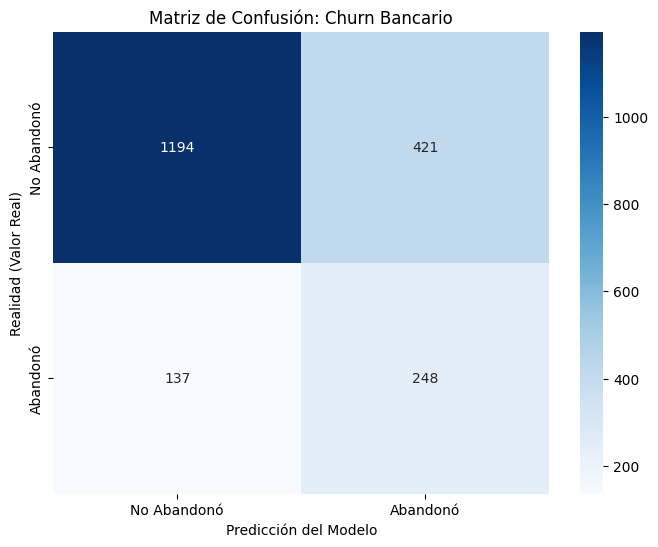

In [38]:
# Se obtiene la matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

# Graficamos
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Abandonó', 'Abandonó'],
            yticklabels=['No Abandonó', 'Abandonó'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Valor Real)')
plt.title('Matriz de Confusión: Churn Bancario')
plt.show()

In [39]:
print(f"Recall: {recall_score(y_test, y_pred_test)}")
print(f"Precision: {precision_score(y_test, y_pred_test)}")
print(f"Tasa Falsos Negativos: {fn / (tp + fn)}")
print(f"Tasa Falsos Positivos: {fp / (tn + fp)}")
print(f"Especificidad: {tn / (tn + fp)}")

Recall: 0.6441558441558441
Precision: 0.37070254110612855
Tasa Falsos Negativos: 0.35584415584415585
Tasa Falsos Positivos: 0.2606811145510836
Especificidad: 0.7393188854489164


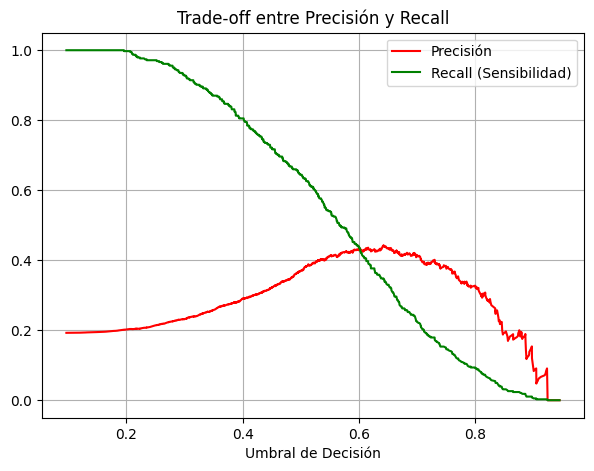

In [40]:
# Se obtienen las probabilidades estimadas de ser 1
probabilidades_test = modelo_balanceado.predict_proba(X_test_scaled)[:, 1]

# Especificamos explícitamente que el '1' es el evento que nos interesa (el abandono)
precision, recall, thresholds = precision_recall_curve(y_test, probabilidades_test, pos_label=1)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], label="Precisión", color="red")
plt.plot(thresholds, recall[:-1], label="Recall (Sensibilidad)", color="green")
plt.xlabel("Umbral de Decisión")
plt.title("Trade-off entre Precisión y Recall")
plt.legend()
plt.grid(True)
plt.show()

+ Obsérvese que la precisión sigue comportándose mal, i.e. no se comporta como la teoría dice.

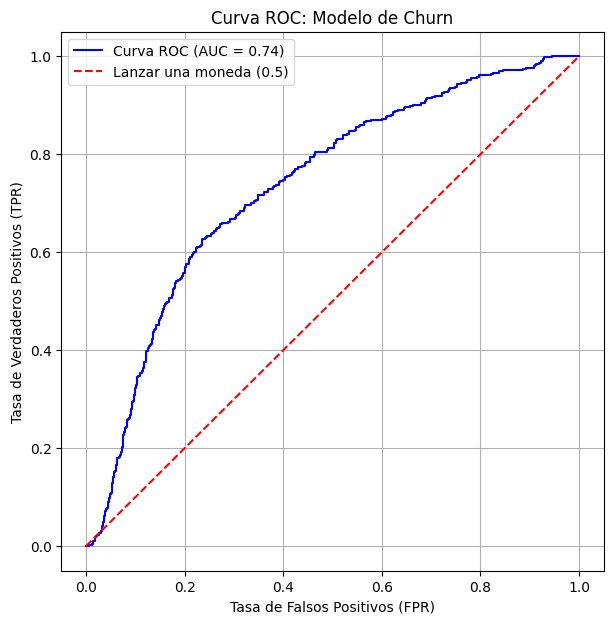

In [41]:
# Se obtiene la curva ROC y el AUC
# Recuerda: probabilidades es la columna [:, 1] de predict_proba
fpr, tpr, thresholds = roc_curve(y_test, probabilidades_test)

# Se obtiene el área bajo la curva (AUC)
auc = roc_auc_score(y_test, probabilidades_test)

# 3. Dibujamos
plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Lanzar una moneda (0.5)') # Línea de referencia

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC: Modelo de Churn')
plt.legend()
plt.grid(True)
plt.show()

+ La penalización NO arregló mucho al modelo.

+ **Segunda hipótesis:** Las variables explicativas no son tan explicativas como pensamos.

+ Vamos a incluir las variables de ubicación geográfica (`Geography`) y género (`Gender`)

+ **PROBLEMA:** `Geography` y `Gender` son variables categóricas y la regresión logísitica necesita que las variables explicativas sean numéricas.

+ Se crearán nuevas variables numéricas a partir de las variables categóricas `Geography` y `Gender`.

+ Opción muy útil: Crear **variables dummies** a.k.a. **one-hot encoding**

+ ¿Cómo funciona? La función toma una columna que contiene $k$ categorías diferentes y la divide en $k$ columnas nuevas.

+ Cada una de estas nuevas columnas representa una categoría y sólo contiene valores de 0 o 1. '1' si el registro original pertenecía a esa categoría y '0' si no pertenecía.

+ En realidad de las nuevas $k$ columnas, una es redundate.

+ Si se tiene "perro", "gato" y "gecko", saber que no es ni "perro" ni "gato" implica automáticamente que es "gecko", por lo que una columna es redundante.

In [42]:
# Transformación de categóricas a numéricas
# 'Gender' se volverá 0 o 1.
# 'Geography' creará columnas para los países (ej. Germany, Spain)
df_procesado = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df_procesado.head()

,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [43]:
# Se definen nuevas variables explicativas
# Ahora incluimos las columnas generadas (puedes verlas con df_procesado.columns)
variables_explicativas = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary',
    'Geography_Germany', 'Geography_Spain', 'Gender_Male'
]

X = df_procesado[variables_explicativas]
y = df_procesado['Exited']

In [44]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,101348.88,False,False,False
1,608,41,1,83807.86,1,112542.58,False,True,False
2,502,42,8,159660.80,3,113931.57,False,False,False
3,699,39,1,0.00,2,93826.63,False,False,False
4,850,43,2,125510.82,1,79084.10,False,True,False


In [45]:
# División train-test y escalado (igual que antes)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2026, stratify = y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenamiento (con pesos balanceados)
modelo_con_ayuda = LogisticRegression(class_weight='balanced')
modelo_con_ayuda.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced')

+ IMPORTANTE: En la función `train_test_split` se agregó el parámetro `stratify = y`

+ Cuando se usa `train_test_split`, la función toma filas al azar.

+ Si por ejemplo, se tiene un 20\% de clientes que abandonan (1), existe el riesgo de que, por pura mala suerte, el dataset de entrenamiento se quede con un 25\% de abandonos y el dataset de prueba se quede con sólo un 5\%.

+ Es decir, que se le daría al modelo en un escenario que no representa la realidad.

+ Al poner `stratify = y`, se le dice a la función que mantenga la misma proporción de la variable respuesta tanto en el entrenamiento como en la prueba.

In [46]:
# Obtenemos las predicciones del modelo sobre las observaciones de entrenamiento
y_pred_train = modelo_con_ayuda.predict(X_train_scaled)
# Obtenemos las predicciones del modelo sobre las observaciones de test
y_pred_test = modelo_con_ayuda.predict(X_test_scaled)

# Calculamos una métrica para problemas de clasificación: accuracy
# Porcentaje de observaciones que la predicción fue correcta
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy en el dataset de entrenamiento: {accuracy_train}")
print(f"Accuracy en el dataset de prueba: {accuracy_test}")

Accuracy en el dataset de entrenamiento: 0.7065
Accuracy en el dataset de prueba: 0.7375


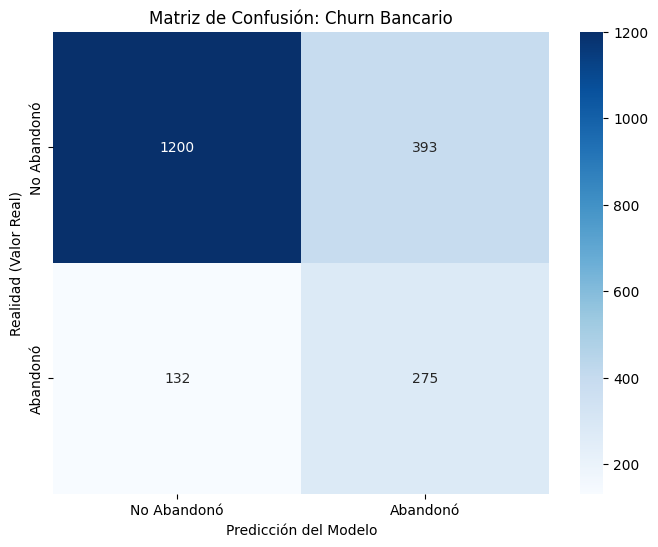

In [47]:
# Se obtiene la matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

# Graficamos
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Abandonó', 'Abandonó'],
            yticklabels=['No Abandonó', 'Abandonó'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Valor Real)')
plt.title('Matriz de Confusión: Churn Bancario')
plt.show()

In [48]:
print(f"Recall: {recall_score(y_test, y_pred_test)}")
print(f"Precision: {precision_score(y_test, y_pred_test)}")
print(f"Tasa Falsos Negativos: {fn / (tp + fn)}")
print(f"Tasa Falsos Positivos: {fp / (tn + fp)}")
print(f"Especificidad: {tn / (tn + fp)}")

Recall: 0.6756756756756757
Precision: 0.4116766467065868
Tasa Falsos Negativos: 0.32432432432432434
Tasa Falsos Positivos: 0.24670433145009416
Especificidad: 0.7532956685499058


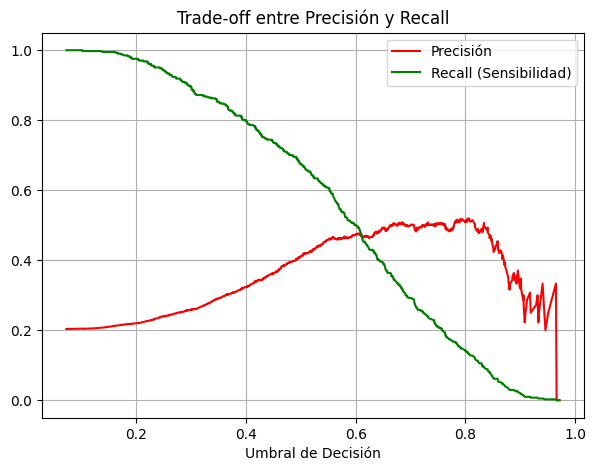

In [49]:
# Se obtienen las probabilidades estimadas de este nuevo modelo
probabilidades_test = modelo_con_ayuda.predict_proba(X_test_scaled)[:, 1]

# Especificamos explícitamente que el '1' es el evento que nos interesa (el abandono)
precision, recall, thresholds = precision_recall_curve(y_test, probabilidades_test, pos_label=1)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], label="Precisión", color="red")
plt.plot(thresholds, recall[:-1], label="Recall (Sensibilidad)", color="green")
plt.xlabel("Umbral de Decisión")
plt.title("Trade-off entre Precisión y Recall")
plt.legend()
plt.grid(True)
plt.show()

+ La precisión se comporta un poquito mejor, pero al final se desvía de la teoría.

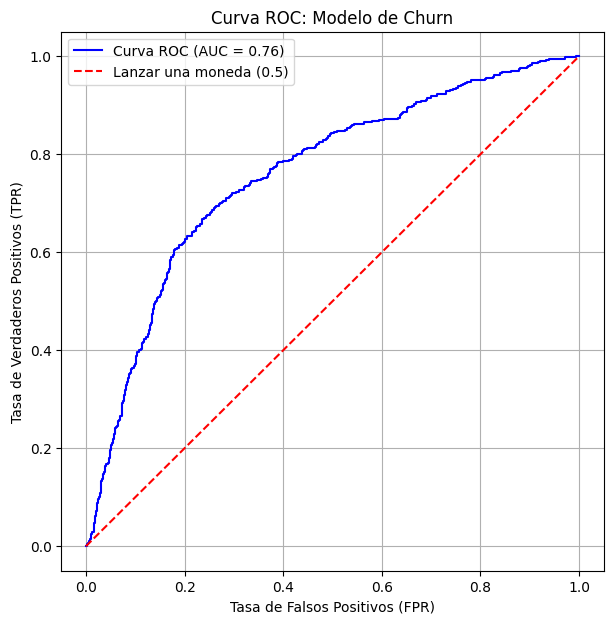

In [50]:
# Se obtiene la curva ROC y el AUC
# Recuerda: probabilidades es la columna [:, 1] de predict_proba
fpr, tpr, thresholds = roc_curve(y_test, probabilidades_test)

# Se obtiene el área bajo la curva (AUC)
auc = roc_auc_score(y_test, probabilidades_test)

# 3. Dibujamos
plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Lanzar una moneda (0.5)') # Línea de referencia

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC: Modelo de Churn')
plt.legend()
plt.grid(True)
plt.show()

+ Se mejoró el modelo muy poco.

+ No forcemos algo que no es.

## ¿Cómo se selecciona el "mejor" umbral?

+ A "ojo" con el punto de cruce de las curvas de precisión y recall

+ En la curva ROC no aparecen los umbrales

+ La manera más metódica es con cross-validation

  + Se proponen varios muchos umbrales y varias divisiones de datos
  + Nos quedamos con el modelo con la mejor métrica

In [51]:
# Configuración
skf = StratifiedKFold(n_splits = 5)
umbrales = np.linspace(0.1, 0.9, 50) # Probamos 50 umbrales distintos
resultados_umbrales = []

for train_index, val_index in skf.split(X, y):
    # Dividir datos del fold
    X_t, X_v = X.iloc[train_index], X.iloc[val_index]
    y_t, y_v = y.iloc[train_index], y.iloc[val_index]

    # Escalar y Entrenar (Importante: escalar dentro del fold)
    scaler_fold = StandardScaler()
    X_t_scaled = scaler_fold.fit_transform(X_t)
    X_v_scaled = scaler_fold.transform(X_v)

    model = LogisticRegression(class_weight='balanced')
    model.fit(X_t_scaled, y_t)

    # Obtener probabilidades de validación
    probs_val = model.predict_proba(X_v_scaled)[:, 1]

    # Evaluar cada umbral en este fold
    ###### En este caso ocupamos el f1-score
    score_por_umbral = [f1_score(y_v, (probs_val > u).astype(int)) for u in umbrales]
    resultados_umbrales.append(score_por_umbral)

# Se promedian los resultados de los 5 folds
promedios = np.mean(resultados_umbrales, axis=0)

# Encontrar el mejor
mejor_umbral = umbrales[np.argmax(promedios)]
print(f"El umbral óptimo basado en F1-Score es: {mejor_umbral:.2f}")

El umbral óptimo basado en F1-Score es: 0.56
